### Create Gaussian Process around dataset

In [43]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType


s_type = ServiceType.CV
df = pd.read_csv("../statics/metrics_20_0.csv")
# 2. Initialize and train
gp = GASK(s_type, show_figures=False)
gp.init_model(df, density=1.0)

INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:multiscale:train_gp_models took 396 ms to execute


### Gaussian Process gives you µ,s for an arbitrary point

In [44]:
import numpy as np
%load_ext autoreload
%autoreload 2

# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0})
# gp.predict(s_type, "max_tp", {'data_quality': 10000, 'cores': 600.0})
gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0, 'model_size': 2.0})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(np.float64(74.12402931107744), np.float64(12.95947696326438))

### Test if the global optimizer converges to a nice result

In [45]:
from agent.components.GaussianProcess import get_empirical_boundaries
%load_ext autoreload
%autoreload 2

from agent.components.Optimizer import local_obj, solve_global
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos = slo_lib.get_slo_for_client("experiment-1", "client-1")

empirical_bounds = get_empirical_boundaries(gp.training_data)[s_type]
# print(empirical_bounds)

starting_point = [6.0, 400] + ([1.0] if s_type == ServiceType.CV else [])
# print(local_obj(starting_point, ServiceType.QR, slos, rask_gp, list(empirical_bounds.values())))
solve_global(s_type, slos, gp, last_assignments=starting_point)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[np.float64(6.0), np.float64(148.40762217958044), np.float64(1.0)]

### Test how much the epsilon should be moved each iteration

In [46]:
import numpy as np

# Convert to a numpy array so we can do math on the whole vector
x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))
raw_bounds = get_empirical_boundaries(gp.training_data)[s_type]
del raw_bounds['max_tp']

# Store these to use for de-normalization inside the objective
ordered_bounds = list(raw_bounds.values())

for e in [1e-5, 1e-3, 1e-2, 5e-2]:
    # val_start uses the original center
    val_start = local_obj(x_norm, s_type, slos, gp, ordered_bounds)

    # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
    val_nudge = local_obj(x_norm + e, s_type, slos, gp, ordered_bounds)

    diff = abs(val_start - val_nudge)
    print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

Eps 1e-05: Change in SLO-F is 0.000000
Eps 0.001: Change in SLO-F is 0.000033
Eps 0.01: Change in SLO-F is 0.000287
Eps 0.05: Change in SLO-F is 0.000517


### Create versatile map of different solutions

Iteration 0: Elite found in bin (np.int64(7), np.int64(7), np.int64(3)) with fitness 0.0555
Iteration 100: Elite found in bin (np.int64(1), np.int64(2), np.int64(2)) with fitness 0.0074
Iteration 200: Elite found in bin (np.int64(4), np.int64(5), np.int64(1)) with fitness 0.0697
Iteration 300: Elite found in bin (np.int64(2), np.int64(6), np.int64(2)) with fitness 0.0076
Iteration 800: Elite found in bin (np.int64(6), np.int64(2), np.int64(3)) with fitness 0.0579
Iteration 900: Elite found in bin (np.int64(8), np.int64(3), np.int64(0)) with fitness 0.4566
Iteration 1800: Elite found in bin (np.int64(4), np.int64(0), np.int64(0)) with fitness 0.3456


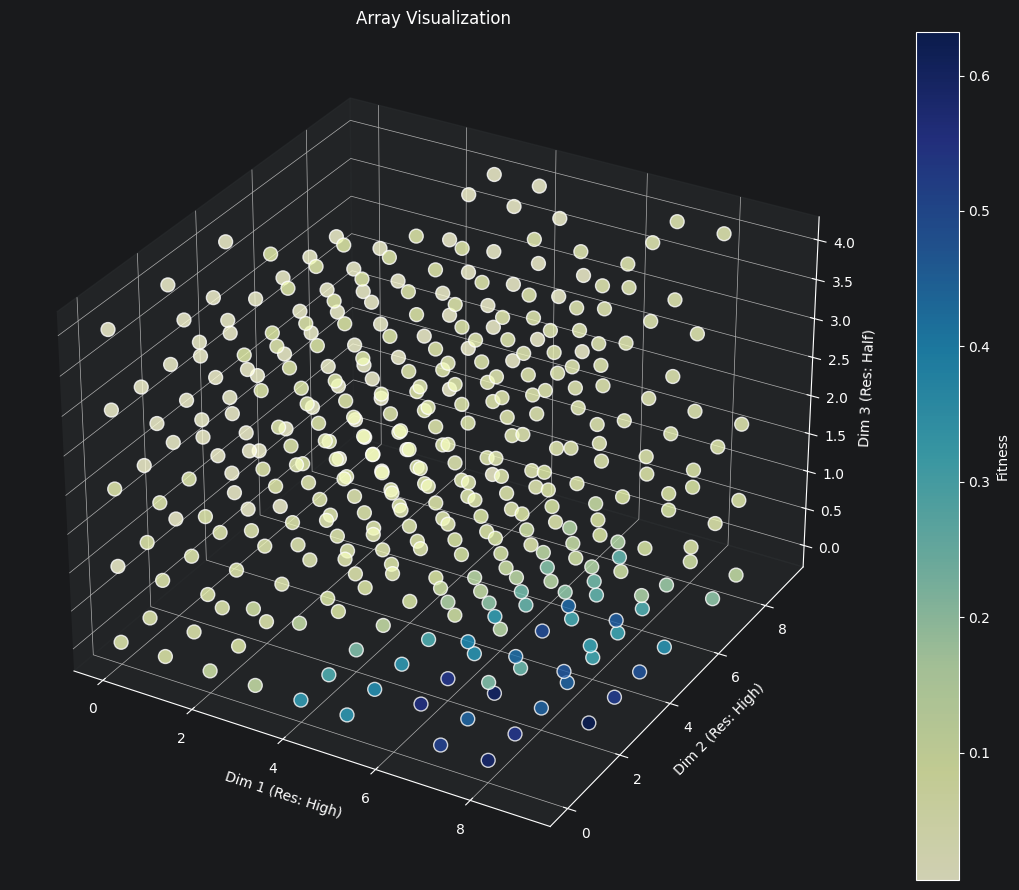

Versatile Candidate: {'coord': array([1.        , 0.27294984, 0.18645752]), 'fitness': np.float64(0.6319349724178022)}
Versatile Candidate: {'coord': array([0.78949392, 0.24191308, 0.        ]), 'fitness': np.float64(0.6061193455349364)}
Versatile Candidate: {'coord': array([0.89389685, 0.09043457, 0.17544683]), 'fitness': np.float64(0.5951330197670478)}
Versatile Candidate: {'coord': array([1.        , 0.47557426, 0.15699155]), 'fitness': np.float64(0.4838580627489737)}
Versatile Candidate: {'coord': array([0.58400426, 0.0605092 , 0.04724452]), 'fitness': np.float64(0.35371388608916093)}
Versatile Candidate: {'coord': array([0.90680489, 0.69049414, 0.        ]), 'fitness': np.float64(0.2899670397231914)}
Versatile Candidate: {'coord': array([0.79131909, 0.34825337, 0.22864564]), 'fitness': np.float64(0.2516732023463592)}
Versatile Candidate: {'coord': array([0.52778861, 0.25657678, 0.        ]), 'fitness': np.float64(0.22610742936401604)}
Versatile Candidate: {'coord': array([0.926263

In [47]:
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites

# 1. Initialize
v_me = VersatileMapElites(s_type, bins=10)

# TODO: I'm getting the black cells because they are not explored.
#  What I can do is force all cells to be explored at least once,
#  or just run gradient descent for each cell multiple (like 5) times.
# 2. Run the illumination
v_me.run_search(slos, gp, ordered_bounds, iterations=2000)
visualize_ndarray(v_me.fitness_table)

# 3. Get n solutions that are high-performing but far apart
diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)
print("\n".join(f"Versatile Candidate: {x}" for x in diverse_set))


### Testing the collapse of an offer

Versatile Candidate: {'coord': array([1.        , 0.27294984, 0.18645752]), 'fitness': np.float64(0.6319349724178022)}
Versatile Candidate: {'coord': array([0.53548692, 0.02395923, 0.        ]), 'fitness': np.float64(0.34561255758466575)}
Versatile Candidate: {'coord': array([1.        , 0.82302026, 0.02197532]), 'fitness': np.float64(0.20716174363662693)}
Versatile Candidate: {'coord': array([0.482304  , 0.51630678, 0.0821453 ]), 'fitness': np.float64(0.09217934561174795)}
Versatile Candidate: {'coord': array([0.17341765, 0.54083361, 0.97492608]), 'fitness': np.float64(0.08421831967003905)}
Versatile Candidate: {'coord': array([0.95389967, 0.24338428, 0.79517948]), 'fitness': np.float64(0.08256848370090325)}
Versatile Candidate: {'coord': array([0.0778985 , 0.06526594, 0.50256013]), 'fitness': np.float64(0.07122787785514767)}
Versatile Candidate: {'coord': array([0.41055718, 0.84955516, 0.50781075]), 'fitness': np.float64(0.06641190539540201)}
Versatile Candidate: {'coord': array([0.6

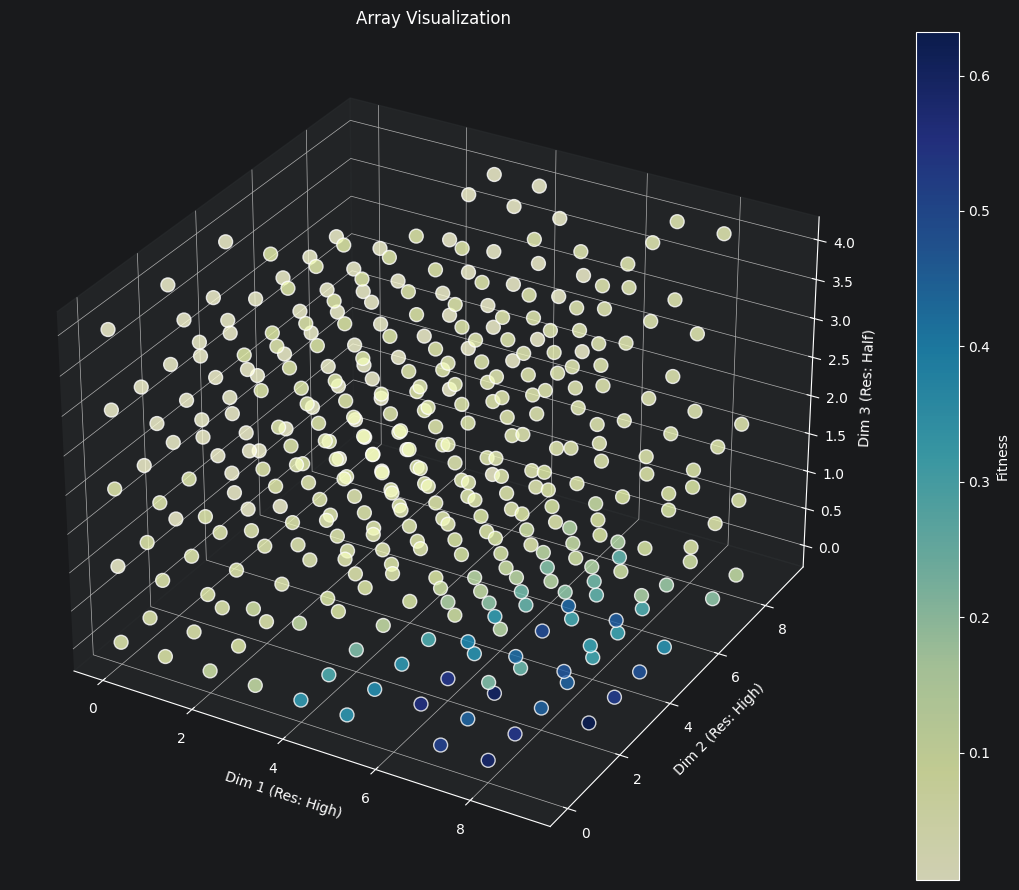

In [48]:
from agent.components.CollapseEngine import collapse_offer

diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.5)
print("\n".join(f"Versatile Candidate: {x}" for x in diverse_set))

visualize_ndarray(v_me.fitness_table)
collapsed_offer = collapse_offer(v_me.fitness_table)
